Import modules:

In [3]:
%matplotlib inline
import numpy as np
from matplotlib import pyplot as pl
import stingray
import h5py

Load data:

In [4]:
indata=h5py.File('/Users/mlparker/data/ufo_timing_data/spectral_data_density_3e-07.hdf5')
spectra_dset=indata['spectra']
energies_dset=indata['energies']

lc_name='example_lightcurve.lc'
temp_filename='time_dependent_ions/ion_concs_%s_%s_%s.npz' % (''.join(lc_name.split('.')[:-1]), 'Fe', '3e-07')

temp_file=np.load(temp_filename)
times=temp_file['times'][:-3]
times=times-min(times)

Define a function to return the light-curve of a given energy band:

In [5]:
def get_binned_lightcurve(energies, eband, spectra_dset):
    '''Returns the lightcurve for a given energy band. \
    Eband should be an iterable object with a lower and upper limit limit'''
    ### Find indices of matching energies. This is horribly inelegant.
    lowindex=np.where(energies>eband[0])[0][0]
    highindex=np.where(energies<eband[1])[-1][-1]
    return np.mean(spectra_dset[:,lowindex:highindex+1],axis=1)

def rebin_lightcurve(times,counts, bintime):
    return 0

Calculate excess variance spectrum:

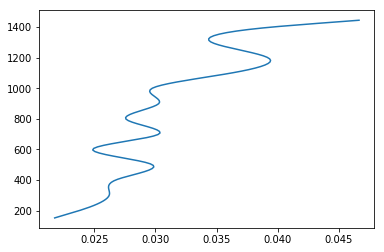

In [7]:
ebins=np.logspace(np.log10(0.3),np.log10(10),1001)
mean_es=[(x+y)/2. for x, y in zip(ebins[:-1],ebins[1:])]

ref_lc=get_binned_lightcurve(energies_dset[:],(0.3,10),spectra_dset)
rms_spectrum=[]
coherence_spectrum=[]

for elow, ehigh in zip(ebins[:-1],ebins[1:]):
    temp_lc=stingray.lightcurve.Lightcurve(get_binned_lightcurve(energies_dset[:],(elow,ehigh),spectra_dset),times)
#     print temp_lc.counts,temp_lc.time
#     pl.plot(temp_lc.time,temp_lc.counts)
#     break
    xs_var=stingray.excess_variance(temp_lc,'fvar')
    coherence=stingray.coherence()
    rms_spectrum.append(xs_var[0])


Plot excess variance:

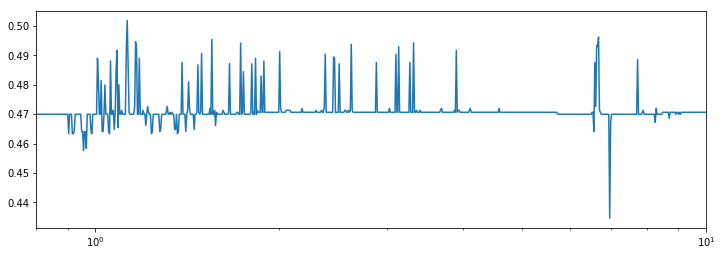

In [83]:
fig=pl.figure(figsize=(12,4))
ax=pl.subplot(111)
ax.set_xscale('log')
ax.set_xlim(0.8,10)

pl.plot(mean_es,rms_spectrum)
pl.show()

Calculate a reference lightcurve from the mean, and plot:

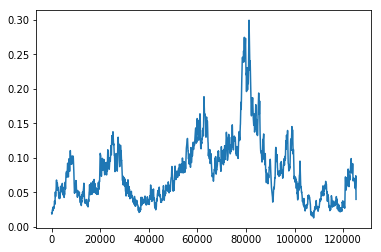

In [26]:
ref_lc=get_binned_lightcurve(energies_dset[:],(0.3,10),spectra_dset)
ref_lc=rebin_lightcurve(times,ref_lc,100s)

pl.plot(times,ref_lc)
pl.show()

Get a test lightcurve for Si XIV:

In [29]:
test_lc=get_binned_lightcurve(energies_dset[:],(1.95,2.05),spectra_dset)

Calculate the cross-spectrum of the two lightcurves, then rebin to 50 log bins in frequency:

In [47]:
sr_ref_lc=stingray.lightcurve.Lightcurve(counts=ref_lc,time=times)
sr_test_lc=stingray.lightcurve.Lightcurve(counts=test_lc,time=times)

# sr_ref_lc.
cross_spec=stingray.AveragedCrossspectrum(sr_test_lc,sr_ref_lc,segment_size=10000)

input_fequencies=cross_spec.freq
# print input_fequencies

# cross_spec.

# fig=pl.figure(figsize=(12,4))
# ax1=pl.subplot(121)
# ax1.set_xscale('log')
# # ax1.set_yscale('log')
# # pl.plot(cross_spec.freq, np.real(cross_spec.power))
# pl.plot(cross_spec.freq, np.angle(cross_spec.power))

[ 0.00010006  0.00020011  0.00030017  0.00040022  0.00050028  0.00060033
  0.00070039  0.00080044  0.0009005   0.00100055  0.00110061  0.00120066
  0.00130072  0.00140077  0.00150083  0.00160088  0.00170094  0.00180099
  0.00190105  0.0020011   0.00210116  0.00220121  0.00230127  0.00240132
  0.00250138  0.00260143  0.00270149  0.00280154  0.0029016   0.00300165
  0.00310171  0.00320176  0.00330182  0.00340187  0.00350193  0.00360198
  0.00370204  0.00380209  0.00390215  0.0040022   0.00410226  0.00420231
  0.00430237  0.00440243  0.00450248  0.00460254  0.00470259  0.00480265
  0.0049027   0.00500276  0.00510281  0.00520287  0.00530292  0.00540298
  0.00550303  0.00560309  0.00570314  0.0058032   0.00590325  0.00600331
  0.00610336  0.00620342  0.00630347  0.00640353  0.00650358  0.00660364
  0.00670369  0.00680375  0.0069038   0.00700386  0.00710391  0.00720397
  0.00730402  0.00740408  0.00750413  0.00760419  0.00770424  0.0078043
  0.00790435  0.00800441  0.00810446  0.00820452  0.